## Data

In [21]:
import pandas as pd
import numpy as np

scored = pd.read_parquet('scored_loan_level_pd.parquet')

print(f"Loaded: {scored.shape}")
print(scored.dtypes)          # issue_d / last_pymnt_d already datetime64
print(f"last_pymnt_d nulls: {scored['last_pymnt_d'].isna().sum()}")
print(scored.head())

Loaded: (1310558, 12)
loan_row_id                      int64
issue_d                 datetime64[us]
issue_q                            str
term_months                    float64
loan_status                        str
default_24m                      int64
default_d_proxy         datetime64[ns]
default_q                          str
pd24m_hat_raw                  float64
pd24m_hat_calibrated           float64
last_pymnt_d            datetime64[us]
loan_amnt                      float64
dtype: object
last_pymnt_d nulls: 0
   loan_row_id    issue_d issue_q  term_months loan_status  default_24m  \
0            0 2015-12-31  2015Q4         36.0  Fully Paid            0   
1            1 2015-12-31  2015Q4         36.0  Fully Paid            0   
2            2 2015-12-31  2015Q4         60.0  Fully Paid            0   
3            3 2015-12-31  2015Q4         60.0     Current            0   
4            4 2015-12-31  2015Q4         60.0  Fully Paid            0   

  default_d_proxy defau

### Preparing Data

In [22]:
# clean quarters and define 24M default timing

scored = scored.copy()

# Ensure datetime
scored['issue_d'] = pd.to_datetime(scored['issue_d'], errors='coerce')

# Use default_d_proxy if available; otherwise use last_pymnt_d as default timing proxy
if 'default_d_proxy' in scored.columns:
    scored['default_d_proxy'] = pd.to_datetime(scored['default_d_proxy'], errors='coerce')
else:
    scored['last_pymnt_d'] = pd.to_datetime(scored['last_pymnt_d'], errors='coerce')
    scored['default_d_proxy'] = scored['last_pymnt_d']

# Origination quarter as Period
scored['issue_q'] = scored['issue_d'].dt.to_period('Q')

# IMPORTANT:
# Initialize as period dtype, not datetime dtype
scored['default_q_24m'] = pd.Series(
    pd.NaT,
    index=scored.index,
    dtype='period[Q-DEC]'
)

# Only loans with default_24m = 1 get a default quarter 
mask_default_24m = scored['default_24m'] == 1

scored.loc[mask_default_24m, 'default_q_24m'] = (
    scored.loc[mask_default_24m, 'default_d_proxy']
    .dt.to_period('Q')
)

# Basic checks
print("Rows:", scored.shape[0])
print("Missing issue_q:", scored['issue_q'].isna().sum())
print(
    "Defaults missing default_q_24m:",
    scored.loc[scored['default_24m'] == 1, 'default_q_24m'].isna().sum()
)

print("\nPD summary:")
display(scored[['pd24m_hat_raw', 'pd24m_hat_calibrated']].describe().round(4))

print("\nQuarter dtypes:")
print(scored[['issue_q', 'default_q_24m']].dtypes)

Rows: 1310558
Missing issue_q: 0
Defaults missing default_q_24m: 0

PD summary:


,pd24m_hat_raw,pd24m_hat_calibrated
count,1.310558e+06,1.310558e+06
mean,1.122000e-01,1.376000e-01
std,7.270000e-02,8.480000e-02
min,0.000000e+00,0.000000e+00
25%,6.130000e-02,7.710000e-02
50%,9.450000e-02,1.178000e-01
75%,1.430000e-01,1.759000e-01
max,1.000000e+00,1.000000e+00



Quarter dtypes:
issue_q          period[Q-DEC]
default_q_24m    period[Q-DEC]
dtype: object


In [23]:
# Estimate empirical default-age curve over 24M horizon

MAX_AGE_Q = 8 # age_q = 0 through 8

# Keep only loans that defaulted within the 24-month target
defaults = scored[scored['default_24m'] == 1].copy()

# Calculate default age in calendar-quarter difference:
# default_age_q = default quarter - issue quarter
defaults['default_age_q'] = (
    defaults['default_q_24m'] - defaults['issue_q']
).apply(lambda x: x.n if pd.notna(x) else np.nan)

# Basic diagnostic
print("Total 24M defaults:", defaults.shape[0])
print("Defaults missing default_age_q:", defaults['default_age_q'].isna().sum())

print("\nDefault-age distribution before filtering:")
display(
    defaults['default_age_q']
    .value_counts(dropna=False)
    .sort_index()
)

# Keep only default ages 0 through 8 quarters
defaults_24m = defaults[
    defaults['default_age_q'].between(0, MAX_AGE_Q)
].copy()

bad_default_ages = defaults[
    ~defaults['default_age_q'].between(0, MAX_AGE_Q)
].copy()

print(f"\nDefaults with valid age 0–{MAX_AGE_Q}:", defaults_24m.shape[0])
print(f"Defaults outside age 0–{MAX_AGE_Q} or missing:", bad_default_ages.shape[0])

# Build empirical age curve
age_curve = (
    defaults_24m
    .groupby('default_age_q')
    .size()
    .reindex(range(MAX_AGE_Q + 1), fill_value=0)
    .reset_index()
)

age_curve.columns = ['age_q', 'default_count']

age_curve['age_weight'] = (
    age_curve['default_count'] / age_curve['default_count'].sum()
)

age_curve['cum_age_weight'] = age_curve['age_weight'].cumsum()

print("\nEmpirical 24M default-age curve:")
display(age_curve)

print("Age-weight sum:", age_curve['age_weight'].sum().round(6))

Total 24M defaults: 167657
Defaults missing default_age_q: 0

Default-age distribution before filtering:


default_age_q
0     2282
1    12788
2    21092
3    25203
4    26254
5    24706
6    22859
7    20390
8    12083
Name: count, dtype: int64


Defaults with valid age 0–8: 167657
Defaults outside age 0–8 or missing: 0

Empirical 24M default-age curve:


,age_q,default_count,age_weight,cum_age_weight
0,0,2282,0.013611,0.013611
1,1,12788,0.076275,0.089886
2,2,21092,0.125804,0.215690
3,3,25203,0.150325,0.366015
4,4,26254,0.156594,0.522609
5,5,24706,0.147360,0.669969
6,6,22859,0.136344,0.806313
7,7,20390,0.121617,0.927930
8,8,12083,0.072070,1.000000


Age-weight sum: 1.0


### Loan-Quarter Data

In [24]:
# Expand loans into loan-quarter panel
# Ages 0 through 8 because quarter-based 24M window spans 9 calendar-quarter buckets

# Create loan id if needed
if 'loan_id' in scored.columns:
    id_col = 'loan_id'
elif 'loan_row_id' in scored.columns:
    id_col = 'loan_row_id'
else:
    scored = scored.reset_index(drop=False).rename(columns={'index': 'loan_row_id'})
    id_col = 'loan_row_id'

print("Using ID column:", id_col)

# Keep only columns needed for panel construction
base_cols = [
    id_col,
    'issue_q',
    'default_24m',
    'default_q_24m',
    'pd24m_hat_raw',
    'pd24m_hat_calibrated'
]

# Optional diagnostics / later sensitivity
if 'term_months' in scored.columns:
    base_cols.append('term_months')

base = scored[base_cols].copy()

# Age grid: 0 through MAX_AGE_Q
ages = pd.DataFrame({'age_q': np.arange(MAX_AGE_Q + 1)})

# Cross join: each loan gets one row per age quarter
panel = base.merge(ages, how='cross')

# Calendar quarter for this loan-age row
panel['quarter'] = panel['issue_q'] + panel['age_q']

# Attach empirical age weights
panel = panel.merge(
    age_curve[['age_q', 'age_weight']],
    on='age_q',
    how='left'
)

# Expected defaults by loan-quarter
panel['expected_default_raw'] = (
    panel['pd24m_hat_raw'] * panel['age_weight']
)

panel['expected_default_calibrated'] = (
    panel['pd24m_hat_calibrated'] * panel['age_weight']
)

# Actual default event in this loan-quarter
panel['default_event'] = (
    (panel['default_24m'] == 1) &
    (panel['quarter'] == panel['default_q_24m'])
).astype(int)

# Checks
print("Loan-level rows:", scored.shape[0])
print("Panel rows:", panel.shape[0])
print("Expected panel rows:", scored.shape[0] * (MAX_AGE_Q + 1))

print("\nTotal actual defaults in panel:")
print(panel['default_event'].sum())

print("\nTotal default_24m loans:")
print(scored['default_24m'].sum())

print("\nTotal expected defaults, raw:")
print(panel['expected_default_raw'].sum().round(2))

print("\nTotal expected defaults, calibrated:")
print(panel['expected_default_calibrated'].sum().round(2))

display(panel.head())

Using ID column: loan_row_id
Loan-level rows: 1310558
Panel rows: 11795022
Expected panel rows: 11795022

Total actual defaults in panel:
167657

Total default_24m loans:
167657

Total expected defaults, raw:
147051.77

Total expected defaults, calibrated:
180272.23


,loan_row_id,issue_q,default_24m,default_q_24m,pd24m_hat_raw,pd24m_hat_calibrated,term_months,age_q,quarter,age_weight,expected_default_raw,expected_default_calibrated,default_event
0,0,2015Q4,0,NaT,0.085047,0.106311,36.0,0,2015Q4,0.013611,0.001158,0.001447,0
1,0,2015Q4,0,NaT,0.085047,0.106311,36.0,1,2016Q1,0.076275,0.006487,0.008109,0
2,0,2015Q4,0,NaT,0.085047,0.106311,36.0,2,2016Q2,0.125804,0.010699,0.013374,0
3,0,2015Q4,0,NaT,0.085047,0.106311,36.0,3,2016Q3,0.150325,0.012785,0.015981,0
4,0,2015Q4,0,NaT,0.085047,0.106311,36.0,4,2016Q4,0.156594,0.013318,0.016648,0


### Quarterly Data with Actual/Expected Mutliplier

In [25]:
# Aggregate loan-quarter panel to calendar-quarter multiplier table

quarter_df = (
    panel
    .groupby('quarter')
    .agg(
        loan_quarters=(id_col, 'size'),
        unique_loans=(id_col, 'nunique'),
        actual_defaults=('default_event', 'sum'),
        expected_defaults_raw=('expected_default_raw', 'sum'),
        expected_defaults_calibrated=('expected_default_calibrated', 'sum'),
        min_age=('age_q', 'min'),
        max_age=('age_q', 'max'),
        n_ages=('age_q', 'nunique'),
        mean_age=('age_q', 'mean')
    )
    .reset_index()
)

# Multipliers
quarter_df['multiplier_raw'] = (
    quarter_df['actual_defaults'] / quarter_df['expected_defaults_raw']
)

quarter_df['multiplier_calibrated'] = (
    quarter_df['actual_defaults'] / quarter_df['expected_defaults_calibrated']
)

# Full age mix means all age buckets 0 through MAX_AGE_Q are present
quarter_df['full_age_mix'] = (
    (quarter_df['min_age'] == 0) &
    (quarter_df['max_age'] == MAX_AGE_Q) &
    (quarter_df['n_ages'] == MAX_AGE_Q + 1)
)

# Diagnostics
print("Quarter range:", quarter_df['quarter'].min(), "to", quarter_df['quarter'].max())
print("Number of quarters:", quarter_df.shape[0])
print("Full-age-mix quarters:", quarter_df['full_age_mix'].sum())

print("\nTotal actual defaults:")
print(quarter_df['actual_defaults'].sum())

print("\nTotal expected defaults, raw:")
print(quarter_df['expected_defaults_raw'].sum().round(2))

print("\nTotal expected defaults, calibrated:")
print(quarter_df['expected_defaults_calibrated'].sum().round(2))

print("\nMultiplier summary:")
display(
    quarter_df[
        ['actual_defaults', 'expected_defaults_raw', 'expected_defaults_calibrated',
         'multiplier_raw', 'multiplier_calibrated',
         'min_age', 'max_age', 'n_ages', 'mean_age', 'full_age_mix']
    ].describe().round(3)
)

display(quarter_df.head(15))
display(quarter_df.tail(15))

Quarter range: 2007Q2 to 2018Q4
Number of quarters: 47
Full-age-mix quarters: 31

Total actual defaults:
167657

Total expected defaults, raw:
147051.77

Total expected defaults, calibrated:
180272.23

Multiplier summary:


,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,multiplier_raw,multiplier_calibrated,min_age,max_age,n_ages,mean_age
count,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000
mean,3567.170,3128.761,3835.579,1.019,0.833,0.766,7.234,7.468,3.174
std,4832.065,3929.097,4814.321,0.292,0.240,1.958,1.958,2.544,1.712
min,0.000,0.050,0.061,0.000,0.000,0.000,0.000,1.000,0.000
25%,117.000,106.066,130.905,0.925,0.751,0.000,8.000,6.500,2.552
50%,825.000,853.027,1041.785,1.072,0.872,0.000,8.000,9.000,2.888
75%,5551.000,5514.286,6752.714,1.188,0.970,0.000,8.000,9.000,3.121
max,15362.000,11896.007,14570.653,1.412,1.163,8.000,8.000,9.000,8.000


,quarter,loan_quarters,unique_loans,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,min_age,max_age,n_ages,mean_age,multiplier_raw,multiplier_calibrated,full_age_mix
0,2007Q2,24,24,0,0.049601,0.060537,0,0,1,0.000000,0.000000,0.000000,False
1,2007Q3,214,214,0,0.763277,0.920276,0,1,2,0.112150,0.000000,0.000000,False
2,2007Q4,603,603,1,4.350728,5.207530,0,2,3,0.394693,0.229847,0.192030,False
3,2008Q1,1614,1614,19,14.023924,16.758367,0,3,4,0.521066,1.354828,1.133762,False
4,2008Q2,2112,2112,34,31.038997,37.216551,0,4,5,1.162405,1.095396,0.913572,False
5,2008Q3,2410,2410,58,45.883037,55.183811,0,5,6,1.895021,1.264084,1.051033,False
6,2008Q4,2993,2993,74,55.898752,67.410110,0,6,7,2.331106,1.323822,1.097758,False
7,2009Q1,3888,3888,80,63.722721,77.096526,0,7,8,2.564300,1.255439,1.037660,False
8,2009Q2,4982,4982,102,72.226512,87.709315,0,8,9,2.781614,1.412224,1.162932,True
9,2009Q3,6319,6319,93,81.854605,99.796164,0,8,9,2.947302,1.136161,0.931900,True


,quarter,loan_quarters,unique_loans,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,min_age,max_age,n_ages,mean_age,multiplier_raw,multiplier_calibrated,full_age_mix
32,2015Q2,526126,526126,6331,6174.955000,7577.193488,0,8,9,3.108636,1.025271,0.835534,True
33,2015Q3,605274,605274,8120,7058.150900,8660.085748,0,8,9,3.115630,1.150443,0.937635,True
34,2015Q4,697271,697271,8601,8041.814312,9866.858978,0,8,9,3.088086,1.069535,0.871706,True
35,2016Q1,785552,785552,9802,9142.736872,11217.896625,0,8,9,3.126381,1.072108,0.873782,True
36,2016Q2,834451,834451,12475,10263.670546,12589.859259,0,8,9,3.374224,1.215452,0.990877,True
37,2016Q3,876418,876418,15362,11111.214706,13624.401706,0,8,9,3.598078,1.382567,1.127536,True
38,2016Q4,919055,919055,14479,11705.820462,14346.360298,0,8,9,3.811676,1.236906,1.009246,True
39,2017Q1,845200,845200,14640,11896.007473,14570.653438,1,8,8,4.445693,1.230665,1.004759,False
40,2017Q2,761287,761287,14065,11167.123760,13671.663077,2,8,7,5.053919,1.259501,1.028770,False
41,2017Q3,665983,665983,12471,9702.240094,11873.417750,3,8,6,5.632327,1.285373,1.050329,False


In [26]:
print("\nAll-quarter m_t path:")
display(
    quarter_df[
        ['quarter',
         'actual_defaults',
         'expected_defaults_raw',
         'expected_defaults_calibrated',
         'multiplier_raw',
         'multiplier_calibrated',
         ]
    ]
)


All-quarter m_t path:


,quarter,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,multiplier_raw,multiplier_calibrated
0,2007Q2,0,0.049601,0.060537,0.000000,0.000000
1,2007Q3,0,0.763277,0.920276,0.000000,0.000000
2,2007Q4,1,4.350728,5.207530,0.229847,0.192030
3,2008Q1,19,14.023924,16.758367,1.354828,1.133762
4,2008Q2,34,31.038997,37.216551,1.095396,0.913572
5,2008Q3,58,45.883037,55.183811,1.264084,1.051033
6,2008Q4,74,55.898752,67.410110,1.323822,1.097758
7,2009Q1,80,63.722721,77.096526,1.255439,1.037660
8,2009Q2,102,72.226512,87.709315,1.412224,1.162932
9,2009Q3,93,81.854605,99.796164,1.136161,0.931900


In [27]:
# Define clean quarterly multiplier sample
# Use full-age-mix quarters as the main sample for satellite regression


quarter_clean = quarter_df[
    quarter_df['full_age_mix']
].copy()

# Valid multiplier checks
quarter_clean['valid_raw_multiplier'] = (
    quarter_clean['expected_defaults_raw'].notna() &
    (quarter_clean['expected_defaults_raw'] > 0) &
    quarter_clean['multiplier_raw'].notna() &
    np.isfinite(quarter_clean['multiplier_raw'])
)

quarter_clean['valid_calibrated_multiplier'] = (
    quarter_clean['expected_defaults_calibrated'].notna() &
    (quarter_clean['expected_defaults_calibrated'] > 0) &
    quarter_clean['multiplier_calibrated'].notna() &
    np.isfinite(quarter_clean['multiplier_calibrated'])
)

# Main clean sample
quarter_clean = quarter_clean[
    quarter_clean['valid_raw_multiplier'] &
    quarter_clean['valid_calibrated_multiplier']
].copy()

# Useful date column for macro merge later
quarter_clean['quarter_start'] = quarter_clean['quarter'].dt.start_time

print("Clean quarterly sample shape:", quarter_clean.shape)
print("Quarter range:", quarter_clean['quarter'].min(), "to", quarter_clean['quarter'].max())
print("Number of clean quarters:", quarter_clean.shape[0])

print("\nMultiplier summary, clean sample:")
display(
    quarter_clean[
        ['actual_defaults',
         'expected_defaults_raw',
         'expected_defaults_calibrated',
         'multiplier_raw',
         'multiplier_calibrated',
         'mean_age']
    ].describe().round(3)
)

print("\nClean quarterly sample:")
display(
    quarter_clean[
        ['quarter',
         'actual_defaults',
         'expected_defaults_raw',
         'expected_defaults_calibrated',
         'multiplier_raw',
         'multiplier_calibrated',
         'mean_age']
    ]
)

Clean quarterly sample shape: (31, 16)
Quarter range: 2009Q2 to 2016Q4
Number of clean quarters: 31

Multiplier summary, clean sample:


,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,multiplier_raw,multiplier_calibrated,mean_age
count,31.000,31.000,31.000,31.000,31.000,31.000
mean,3347.806,3022.045,3708.990,1.045,0.850,2.897
std,4520.410,3712.855,4552.636,0.146,0.121,0.323
min,93.000,72.227,87.709,0.765,0.619,2.409
25%,225.500,250.608,309.687,0.925,0.751,2.648
50%,914.000,996.297,1226.871,1.059,0.859,2.888
75%,4594.000,4972.708,6103.223,1.116,0.904,3.051
max,15362.000,11705.820,14346.360,1.412,1.163,3.812



Clean quarterly sample:


,quarter,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,multiplier_raw,multiplier_calibrated,mean_age
8,2009Q2,102,72.226512,87.709315,1.412224,1.162932,2.781614
9,2009Q3,93,81.854605,99.796164,1.136161,0.931900,2.947302
10,2009Q4,109,90.919489,111.394254,1.198863,0.978506,2.888240
11,2010Q1,112,99.272729,122.300941,1.128205,0.915774,2.829378
12,2010Q2,122,112.859011,139.508234,1.080995,0.874500,2.413927
13,2010Q3,160,144.897550,179.128954,1.104228,0.893211,2.408608
14,2010Q4,199,186.417600,230.394322,1.067496,0.863737,2.614739
15,2011Q1,175,228.883161,282.842802,0.764582,0.618718,2.791067
16,2011Q2,252,272.333254,336.531604,0.925337,0.748815,2.872724
17,2011Q3,330,322.307453,398.201782,1.023867,0.828726,2.955252


### Merge with Macro Factors

In [28]:
# ============================================================
# Download and construct quarterly macro variables from FRED
#
# Main macro variables:
#   - real GDP growth, lagged one quarter
#   - unemployment-rate change, lagged one quarter
#   - Baa-Treasury credit-spread change, lagged one quarter
# ============================================================

import pandas as pd
import numpy as np

# ----------------------------
# Helper: read one FRED series directly from CSV
# ----------------------------

def read_fred_series(series_id, new_name):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    
    df = pd.read_csv(url)
    df.columns = ['date', new_name]
    
    df['date'] = pd.to_datetime(df['date'])
    df[new_name] = pd.to_numeric(df[new_name], errors='coerce')
    
    return df.set_index('date')


# ----------------------------
# Define macro window from full Layer 2 quarter table
# ----------------------------

q_min = quarter_df['quarter'].min()
q_max = quarter_df['quarter'].max()

# Need extra lookback because:
# GDP YoY uses t-4, then lagged one quarter uses t-5
# two years is conservative and simple
start_date = q_min.start_time - pd.DateOffset(years=2)
end_date = q_max.end_time

print("Layer 2 quarter range:", q_min, "to", q_max)
print("Macro window:", start_date.date(), "to", end_date.date())


# ----------------------------
# Download FRED series
# ----------------------------

gdp = read_fred_series('GDPC1', 'real_gdp')             # Quarterly real GDP
unrate = read_fred_series('UNRATE', 'unrate')          # Monthly unemployment rate
spread = read_fred_series('BAA10YM', 'baa10y_spread')  # Monthly Baa - 10Y Treasury spread


# Restrict to required window
gdp = gdp.loc[start_date:end_date]
unrate = unrate.loc[start_date:end_date]
spread = spread.loc[start_date:end_date]


# ----------------------------
# Convert each series to quarterly frequency
# ----------------------------

# GDP: already quarterly; use last observed value in quarter
gdp_q = gdp.dropna().copy()
gdp_q['quarter'] = gdp_q.index.to_period('Q')

gdp_q = (
    gdp_q
    .groupby('quarter')
    .last()
    .reset_index()
)

# Unemployment: use end-of-quarter monthly value
unrate_q = unrate.dropna().copy()
unrate_q['quarter'] = unrate_q.index.to_period('Q')

unrate_q = (
    unrate_q
    .groupby('quarter')
    .last()
    .reset_index()
)

# Credit spread: use end-of-quarter monthly value
spread_q = spread.dropna().copy()
spread_q['quarter'] = spread_q.index.to_period('Q')

spread_q = (
    spread_q
    .groupby('quarter')
    .last()
    .reset_index()
)


# ----------------------------
# Merge quarterly macro series
# ----------------------------

macro_q = (
    gdp_q
    .merge(unrate_q, on='quarter', how='outer')
    .merge(spread_q, on='quarter', how='outer')
    .sort_values('quarter')
    .reset_index(drop=True)
)


# ----------------------------
# Transform macro variables
# ----------------------------

# GDP growth
macro_q['real_gdp_growth_qoq'] = macro_q['real_gdp'].pct_change()
macro_q['real_gdp_growth_qoq_ann'] = (1 + macro_q['real_gdp_growth_qoq'])**4 - 1
macro_q['real_gdp_growth_yoy'] = macro_q['real_gdp'].pct_change(4)

# Unemployment-rate change, in percentage points
macro_q['unrate_diff'] = macro_q['unrate'].diff()

# Baa-Treasury spread change, in percentage points
macro_q['baa10y_spread_diff'] = macro_q['baa10y_spread'].diff()


# ----------------------------
# Lag macro variables by one quarter
# ----------------------------

macro_q['real_gdp_growth_yoy_l1'] = macro_q['real_gdp_growth_yoy'].shift(1)
macro_q['real_gdp_growth_qoq_ann_l1'] = macro_q['real_gdp_growth_qoq_ann'].shift(1)

macro_q['unrate_diff_l1'] = macro_q['unrate_diff'].shift(1)
macro_q['baa10y_spread_diff_l1'] = macro_q['baa10y_spread_diff'].shift(1)


# ----------------------------
# Main macro columns for baseline regression
# ----------------------------

macro_cols_main = [
    'real_gdp_growth_yoy_l1',
    'unrate_diff_l1',
    'baa10y_spread_diff_l1'
]


# ----------------------------
# Display and checks
# ----------------------------

print("\nMacro quarterly data:")
display(
    macro_q[
        ['quarter',
         'real_gdp',
         'real_gdp_growth_yoy',
         'real_gdp_growth_yoy_l1',
         'unrate',
         'unrate_diff',
         'unrate_diff_l1',
         'baa10y_spread',
         'baa10y_spread_diff',
         'baa10y_spread_diff_l1']
    ].tail(25)
)

print("\nMacro quarter range:")
print(macro_q['quarter'].min(), "to", macro_q['quarter'].max())

print("\nMissing values in main lagged macro variables:")
display(macro_q[macro_cols_main].isna().sum())

print("\nNon-missing counts in main lagged macro variables:")
display(macro_q[macro_cols_main].notna().sum())

Layer 2 quarter range: 2007Q2 to 2018Q4
Macro window: 2005-04-01 to 2018-12-31

Macro quarterly data:


,quarter,real_gdp,real_gdp_growth_yoy,real_gdp_growth_yoy_l1,unrate,unrate_diff,unrate_diff_l1,baa10y_spread,baa10y_spread_diff,baa10y_spread_diff_l1
30,2012Q4,17489.852,0.015519,0.025737,7.9,0.1,-0.4,2.91,-0.21,-0.28
31,2013Q1,17662.400,0.017009,0.015519,7.5,-0.4,0.1,2.89,-0.02,-0.21
32,2013Q2,17709.671,0.015199,0.017009,7.5,0.0,-0.4,2.89,0.00,-0.02
33,2013Q3,17860.450,0.022370,0.015199,7.2,-0.3,0.0,2.66,-0.23,0.00
34,2013Q4,18016.147,0.030091,0.022370,6.7,-0.5,-0.3,2.48,-0.18,-0.23
35,2014Q1,17953.974,0.016508,0.030091,6.7,0.0,-0.5,2.34,-0.14,-0.18
36,2014Q2,18185.911,0.026892,0.016508,6.1,-0.6,0.0,2.20,-0.14,-0.14
37,2014Q3,18406.941,0.030598,0.026892,5.9,-0.2,-0.6,2.27,0.07,-0.14
38,2014Q4,18500.031,0.026858,0.030598,5.6,-0.3,-0.2,2.53,0.26,0.07
39,2015Q1,18666.621,0.039693,0.026858,5.4,-0.2,-0.3,2.50,-0.03,0.26



Macro quarter range:
2005Q2 to 2018Q4

Missing values in main lagged macro variables:


real_gdp_growth_yoy_l1    5
unrate_diff_l1            2
baa10y_spread_diff_l1     2
dtype: int64


Non-missing counts in main lagged macro variables:


real_gdp_growth_yoy_l1    50
unrate_diff_l1            53
baa10y_spread_diff_l1     53
dtype: int64

In [29]:
# Merge macro variables into quarterly multiplier table
# Keep both raw and calibrated multipliers

# Merge macro data to all Layer 2 quarters
quarter_macro = (
    quarter_df
    .merge(
        macro_q,
        on='quarter',
        how='left'
    )
    .sort_values('quarter')
    .reset_index(drop=True)
)

# Main and sensitivity targets
target_raw = 'multiplier_raw'
target_cal = 'multiplier_calibrated'

# Main macro variables
macro_cols_main = [
    'real_gdp_growth_yoy_l1',
    'unrate_diff_l1',
    'baa10y_spread_diff_l1'
]

# Complete macro flag
quarter_macro['has_main_macro'] = (
    quarter_macro[macro_cols_main]
    .notna()
    .all(axis=1)
)

# Valid target flags
quarter_macro['valid_multiplier_raw'] = (
    quarter_macro[target_raw].notna() &
    np.isfinite(quarter_macro[target_raw])
)

quarter_macro['valid_multiplier_calibrated'] = (
    quarter_macro[target_cal].notna() &
    np.isfinite(quarter_macro[target_cal])
)

# Baseline regression frame:
# full-age-mix quarters + complete macro variables + both multipliers valid
macro_reg_df = quarter_macro[
    quarter_macro['full_age_mix'] &
    quarter_macro['has_main_macro'] &
    quarter_macro['valid_multiplier_raw'] &
    quarter_macro['valid_multiplier_calibrated']
].copy()

print("Full quarterly multiplier table:", quarter_df.shape)
print("Merged quarter_macro:", quarter_macro.shape)
print("Rows with complete macro vars:", quarter_macro['has_main_macro'].sum())
print("Baseline macro regression sample:", macro_reg_df.shape)

print("\nFull quarter range:")
print(quarter_macro['quarter'].min(), "to", quarter_macro['quarter'].max())

print("\nRegression quarter range:")
print(macro_reg_df['quarter'].min(), "to", macro_reg_df['quarter'].max())

print("\nRegression frame:")
display(
    macro_reg_df[
        ['quarter',
         'actual_defaults',
         'expected_defaults_raw',
         'expected_defaults_calibrated',
         'multiplier_raw',
         'multiplier_calibrated',
         'real_gdp_growth_yoy_l1',
         'unrate_diff_l1',
         'baa10y_spread_diff_l1']
    ]
)

print("\nMissing values in merged full table:")
display(
    quarter_macro[
        ['multiplier_raw',
         'multiplier_calibrated'] + macro_cols_main
    ].isna().sum()
)

Full quarterly multiplier table: (47, 13)
Merged quarter_macro: (47, 28)
Rows with complete macro vars: 47
Baseline macro regression sample: (31, 28)

Full quarter range:
2007Q2 to 2018Q4

Regression quarter range:
2009Q2 to 2016Q4

Regression frame:


,quarter,actual_defaults,expected_defaults_raw,expected_defaults_calibrated,multiplier_raw,multiplier_calibrated,real_gdp_growth_yoy_l1,unrate_diff_l1,baa10y_spread_diff_l1
8,2009Q2,102,72.226512,87.709315,1.412224,1.162932,-0.032342,1.4,-0.41
9,2009Q3,93,81.854605,99.796164,1.136161,0.931900,-0.039788,0.8,-1.82
10,2009Q4,109,90.919489,111.394254,1.198863,0.978506,-0.031328,0.3,-0.87
11,2010Q1,112,99.272729,122.300941,1.128205,0.915774,0.001056,0.1,-0.13
12,2010Q2,122,112.859011,139.508234,1.080995,0.874500,0.017453,0.0,-0.24
13,2010Q3,160,144.897550,179.128954,1.104228,0.893211,0.029136,-0.5,0.49
14,2010Q4,199,186.417600,230.394322,1.067496,0.863737,0.033442,0.1,-0.02
15,2011Q1,175,228.883161,282.842802,0.764582,0.618718,0.027760,-0.2,-0.20
16,2011Q2,252,272.333254,336.531604,0.925337,0.748815,0.020378,-0.3,-0.19
17,2011Q3,330,322.307453,398.201782,1.023867,0.828726,0.017437,0.1,0.13



Missing values in merged full table:


multiplier_raw            0
multiplier_calibrated     0
real_gdp_growth_yoy_l1    0
unrate_diff_l1            0
baa10y_spread_diff_l1     0
dtype: int64

## Satellite Regression

### Baseline Set 

In [41]:
# ================================================
# Baseline satellite regressions
# Sample: clean full-age-mix quarters
# Targets: raw and calibrated log multipliers
# Errors: HAC / Newey-West robust standard errors
# ================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# Model specifications
# ----------------------------

model_specs = {
    'M1_unemp': [
        'unrate_diff_l1'
    ],
    'M2_unemp_spread': [
        'unrate_diff_l1',
        'baa10y_spread_diff_l1'
    ],
    'M3_unemp_gdp': [
        'unrate_diff_l1',
        'real_gdp_growth_yoy_l1'
    ],
    'M4_unemp_gdp_spread': [
        'unrate_diff_l1',
        'real_gdp_growth_yoy_l1',
        'baa10y_spread_diff_l1'
    ],
    'M5_unemp_time_trend': [
        'unrate_diff_l1',
        'time_trend'
    ]
}

# Calibrated PD is the PRIMARY reporting basis; raw PD is the sensitivity.
# Dict order controls row/column order downstream, so calibrated is listed first.
target_map = {
    'calibrated': 'multiplier_calibrated',   # PRIMARY
    'raw':        'multiplier_raw'            # sensitivity
}


# ----------------------------
# Helper function
# ----------------------------

def run_satellite_suite(df, sample_name, model_specs, target_map, hac_lags=1):
    """
    Runs satellite regressions for multiple targets and model specs.

    Uses:
      - log multiplier as dependent variable
      - OLS point estimates
      - HAC / Newey-West robust standard errors
      - AIC/BIC from OLS likelihood
    """
    
    work = df.copy()
    
    # Ensure time order and create simple time trend
    work = work.sort_values('quarter').reset_index(drop=True)
    work['time_trend'] = np.arange(len(work))
    
    all_models = {}
    coef_rows = []
    compare_rows = []
    
    for target_label, target_col in target_map.items():
        
        log_target_col = f'log_{target_col}'
        
        # log only defined for strictly positive multipliers
        work[log_target_col] = np.where(
            work[target_col] > 0,
            np.log(work[target_col]),
            np.nan
        )
        
        for model_id, x_cols in model_specs.items():
            
            model_df = work[
                ['quarter', log_target_col, target_col] + x_cols
            ].replace([np.inf, -np.inf], np.nan).dropna().copy()
            
            y = model_df[log_target_col]
            X = sm.add_constant(model_df[x_cols])
            
            model = sm.OLS(y, X).fit(
                cov_type='HAC',
                cov_kwds={'maxlags': hac_lags}
            )
            
            model_name = f'{sample_name}__{target_label}__{model_id}'
            
            all_models[model_name] = {
                'model': model,
                'data': model_df,
                'sample': sample_name,
                'target_label': target_label,
                'target_col': target_col,
                'model_id': model_id,
                'x_cols': x_cols
            }
            
            # Model-level comparison row
            compare_rows.append({
                'sample': sample_name,
                'target': target_label,
                'model_id': model_id,
                'nobs': int(model.nobs),
                'k_predictors': len(x_cols),
                'r2': model.rsquared,
                'adj_r2': model.rsquared_adj,
                'aic': model.aic,
                'bic': model.bic,
                'dep_var': log_target_col,
                'x_vars': ', '.join(x_cols)
            })
            
            # Coefficient-level rows
            for term in model.params.index:
                coef_rows.append({
                    'sample': sample_name,
                    'target': target_label,
                    'model_id': model_id,
                    'term': term,
                    'coef': model.params[term],
                    'std_err_HAC': model.bse[term],
                    't_stat_HAC': model.tvalues[term],
                    'p_value_HAC': model.pvalues[term],
                    'nobs': int(model.nobs),
                    'r2': model.rsquared,
                    'adj_r2': model.rsquared_adj,
                    'aic': model.aic,
                    'bic': model.bic
                })
            
            print("\n" + "=" * 90)
            print(model_name)
            print("N:", int(model.nobs))
            print("R2:", round(model.rsquared, 4))
            print("Adj R2:", round(model.rsquared_adj, 4))
            print("AIC:", round(model.aic, 2))
            print("BIC:", round(model.bic, 2))
            print("HAC/Newey-West maxlags:", hac_lags)
            print("=" * 90)
            print(model.summary())
    
    coef_table = pd.DataFrame(coef_rows)
    compare_table = pd.DataFrame(compare_rows)
    
    return all_models, coef_table, compare_table


# ----------------------------
# Run baseline suite
# ----------------------------

baseline_models, baseline_coef_table, baseline_compare_table = run_satellite_suite(
    df=macro_reg_df,
    sample_name='baseline_full_age_mix',
    model_specs=model_specs,
    target_map=target_map,
    hac_lags=1
)


# ----------------------------
# Display compact baseline comparison
# ----------------------------

baseline_compare_display = baseline_compare_table.copy()

for col in ['r2', 'adj_r2', 'aic', 'bic']:
    baseline_compare_display[col] = baseline_compare_display[col].round(4)

print("\nBaseline model comparison:")
display(baseline_compare_display)


baseline_coef_display = baseline_coef_table.copy()

for col in ['coef', 'std_err_HAC', 't_stat_HAC', 'p_value_HAC', 'r2', 'adj_r2', 'aic', 'bic']:
    baseline_coef_display[col] = baseline_coef_display[col].round(4)

print("\nBaseline coefficient table:")
display(baseline_coef_display)

baseline_coef_table.to_csv("satellite_coefficients_baseline.csv", index=False)


baseline_full_age_mix__calibrated__M1_unemp
N: 31
R2: 0.3281
Adj R2: 0.3049
AIC: -43.7
BIC: -40.83
HAC/Newey-West maxlags: 1
                                OLS Regression Results                               
Dep. Variable:     log_multiplier_calibrated   R-squared:                       0.328
Model:                                   OLS   Adj. R-squared:                  0.305
Method:                        Least Squares   F-statistic:                     51.86
Date:                       Thu, 25 Jun 2026   Prob (F-statistic):           6.28e-08
Time:                               11:39:00   Log-Likelihood:                 23.849
No. Observations:                         31   AIC:                            -43.70
Df Residuals:                             29   BIC:                            -40.83
Df Model:                                  1                                         
Covariance Type:                         HAC                                         
              

,sample,target,model_id,nobs,k_predictors,r2,adj_r2,aic,bic,dep_var,x_vars
0,baseline_full_age_mix,calibrated,M1_unemp,31,1,0.3281,0.3049,-43.6970,-40.8290,log_multiplier_calibrated,unrate_diff_l1
1,baseline_full_age_mix,calibrated,M2_unemp_spread,31,2,0.3321,0.2844,-41.8844,-37.5824,log_multiplier_calibrated,"unrate_diff_l1, baa10y_spread_diff_l1"
2,baseline_full_age_mix,calibrated,M3_unemp_gdp,31,2,0.3286,0.2807,-41.7235,-37.4215,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1"
3,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,31,3,0.3376,0.2640,-40.1415,-34.4056,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
4,baseline_full_age_mix,calibrated,M5_unemp_time_trend,31,2,0.4149,0.3731,-45.9879,-41.6859,log_multiplier_calibrated,"unrate_diff_l1, time_trend"
5,baseline_full_age_mix,raw,M1_unemp,31,1,0.3177,0.2941,-44.2466,-41.3786,log_multiplier_raw,unrate_diff_l1
6,baseline_full_age_mix,raw,M2_unemp_spread,31,2,0.3226,0.2743,-42.4739,-38.1719,log_multiplier_raw,"unrate_diff_l1, baa10y_spread_diff_l1"
7,baseline_full_age_mix,raw,M3_unemp_gdp,31,2,0.3181,0.2694,-42.2652,-37.9632,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1"
8,baseline_full_age_mix,raw,M4_unemp_gdp_spread,31,3,0.3282,0.2536,-40.7300,-34.9940,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
9,baseline_full_age_mix,raw,M5_unemp_time_trend,31,2,0.3984,0.3555,-46.1521,-41.8501,log_multiplier_raw,"unrate_diff_l1, time_trend"



Baseline coefficient table:


,sample,target,model_id,term,coef,std_err_HAC,t_stat_HAC,p_value_HAC,nobs,r2,adj_r2,aic,bic
0,baseline_full_age_mix,calibrated,M1_unemp,const,-0.1573,0.0229,-6.8632,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
1,baseline_full_age_mix,calibrated,M1_unemp,unrate_diff_l1,0.2034,0.0282,7.2016,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
2,baseline_full_age_mix,calibrated,M2_unemp_spread,const,-0.1537,0.0229,-6.7172,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
3,baseline_full_age_mix,calibrated,M2_unemp_spread,unrate_diff_l1,0.2167,0.0357,6.0644,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
4,baseline_full_age_mix,calibrated,M2_unemp_spread,baa10y_spread_diff_l1,0.0241,0.0429,0.5610,0.5748,31,0.3321,0.2844,-41.8844,-37.5824
5,baseline_full_age_mix,calibrated,M3_unemp_gdp,const,-0.1533,0.0244,-6.2737,0.0000,31,0.3286,0.2807,-41.7235,-37.4215
6,baseline_full_age_mix,calibrated,M3_unemp_gdp,unrate_diff_l1,0.1927,0.0504,3.8257,0.0001,31,0.3286,0.2807,-41.7235,-37.4215
7,baseline_full_age_mix,calibrated,M3_unemp_gdp,real_gdp_growth_yoy_l1,-0.2859,1.0886,-0.2626,0.7929,31,0.3286,0.2807,-41.7235,-37.4215
8,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,const,-0.1358,0.0401,-3.3818,0.0007,31,0.3376,0.2640,-40.1415,-34.4056
9,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,unrate_diff_l1,0.1872,0.0541,3.4598,0.0005,31,0.3376,0.2640,-40.1415,-34.4056


### Robustness Set

In [31]:
# ================================================
# Robustness satellite regressions
# Sample: full available quarterly range
# Note: edge quarters may have incomplete age mix
# Targets: raw and calibrated log multipliers
# Errors: HAC / Newey-West robust standard errors
# ================================================

# Full sample uses all quarters after macro merge.
# The function automatically:
#   - creates time_trend
#   - drops rows with missing macro variables
#   - drops rows where multiplier <= 0 because log(0) is undefined.
#
# Since model_specs now includes M5_unemp_time_trend,
# this runs 2 targets × 5 specs = 10 robustness models.

robust_df = quarter_macro.copy()

robust_models, robust_coef_table, robust_compare_table = run_satellite_suite(
    df=robust_df,
    sample_name='robust_full_47q',
    model_specs=model_specs,
    target_map=target_map,
    hac_lags=1
)


# ----------------------------
# Display compact robustness comparison
# ----------------------------

robust_compare_display = robust_compare_table.copy()

for col in ['r2', 'adj_r2', 'aic', 'bic']:
    robust_compare_display[col] = robust_compare_display[col].round(4)

print("\nRobustness model comparison:")
display(robust_compare_display)


robust_coef_display = robust_coef_table.copy()

for col in ['coef', 'std_err_HAC', 't_stat_HAC', 'p_value_HAC', 'r2', 'adj_r2', 'aic', 'bic']:
    robust_coef_display[col] = robust_coef_display[col].round(4)

print("\nRobustness coefficient table:")
display(robust_coef_display)


# ----------------------------
# Combine baseline + robustness results
# ----------------------------

all_compare_table = pd.concat(
    [baseline_compare_table, robust_compare_table],
    ignore_index=True
)

all_coef_table = pd.concat(
    [baseline_coef_table, robust_coef_table],
    ignore_index=True
)

all_compare_display = all_compare_table.copy()

for col in ['r2', 'adj_r2', 'aic', 'bic']:
    all_compare_display[col] = all_compare_display[col].round(4)

print("\nAll model comparison:")
display(all_compare_display)


all_coef_display = all_coef_table.copy()

for col in ['coef', 'std_err_HAC', 't_stat_HAC', 'p_value_HAC', 'r2', 'adj_r2', 'aic', 'bic']:
    all_coef_display[col] = all_coef_display[col].round(4)

print("\nAll coefficient results:")
display(all_coef_display)


# NOTE: all files are written in the 'Result Tables and Figures' section below,
# into artifacts_component2/ 


robust_full_47q__calibrated__M1_unemp
N: 45
R2: 0.0733
Adj R2: 0.0518
AIC: 9.31
BIC: 12.92
HAC/Newey-West maxlags: 1
                                OLS Regression Results                               
Dep. Variable:     log_multiplier_calibrated   R-squared:                       0.073
Model:                                   OLS   Adj. R-squared:                  0.052
Method:                        Least Squares   F-statistic:                     21.43
Date:                       Thu, 25 Jun 2026   Prob (F-statistic):           3.37e-05
Time:                               11:27:38   Log-Likelihood:                -2.6529
No. Observations:                         45   AIC:                             9.306
Df Residuals:                             43   BIC:                             12.92
Df Model:                                  1                                         
Covariance Type:                         HAC                                         
                     c

c:\venvs\stress\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\venvs\stress\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)



robust_full_47q__raw__M4_unemp_gdp_spread
N: 45
R2: 0.0794
Adj R2: 0.012
AIC: 13.18
BIC: 20.41
HAC/Newey-West maxlags: 1
                            OLS Regression Results                            
Dep. Variable:     log_multiplier_raw   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     6.359
Date:                Thu, 25 Jun 2026   Prob (F-statistic):            0.00122
Time:                        11:27:38   Log-Likelihood:                -2.5897
No. Observations:                  45   AIC:                             13.18
Df Residuals:                      41   BIC:                             20.41
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                             coef    std err          z      P>|z|      [0.025      0.97

,sample,target,model_id,nobs,k_predictors,r2,adj_r2,aic,bic,dep_var,x_vars
0,robust_full_47q,calibrated,M1_unemp,45,1,0.0733,0.0518,9.3057,12.9191,log_multiplier_calibrated,unrate_diff_l1
1,robust_full_47q,calibrated,M2_unemp_spread,45,2,0.0831,0.0394,10.8302,16.2502,log_multiplier_calibrated,"unrate_diff_l1, baa10y_spread_diff_l1"
2,robust_full_47q,calibrated,M3_unemp_gdp,45,2,0.0814,0.0377,10.9108,16.3308,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1"
3,robust_full_47q,calibrated,M4_unemp_gdp_spread,45,3,0.0864,0.0196,12.6642,19.8908,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
4,robust_full_47q,calibrated,M5_unemp_time_trend,45,2,0.1794,0.1404,5.8329,11.2529,log_multiplier_calibrated,"unrate_diff_l1, time_trend"
5,robust_full_47q,raw,M1_unemp,45,1,0.0642,0.0424,9.9152,13.5285,log_multiplier_raw,unrate_diff_l1
6,robust_full_47q,raw,M2_unemp_spread,45,2,0.0753,0.0313,11.3764,16.7964,log_multiplier_raw,"unrate_diff_l1, baa10y_spread_diff_l1"
7,robust_full_47q,raw,M3_unemp_gdp,45,2,0.0737,0.0296,11.4554,16.8754,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1"
8,robust_full_47q,raw,M4_unemp_gdp_spread,45,3,0.0794,0.0120,13.1794,20.4061,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
9,robust_full_47q,raw,M5_unemp_time_trend,45,2,0.1716,0.1322,6.4272,11.8472,log_multiplier_raw,"unrate_diff_l1, time_trend"



Robustness coefficient table:


,sample,target,model_id,term,coef,std_err_HAC,t_stat_HAC,p_value_HAC,nobs,r2,adj_r2,aic,bic
0,robust_full_47q,calibrated,M1_unemp,const,-0.1630,0.0385,-4.2306,0.0000,45,0.0733,0.0518,9.3057,12.9191
1,robust_full_47q,calibrated,M1_unemp,unrate_diff_l1,0.1814,0.0392,4.6295,0.0000,45,0.0733,0.0518,9.3057,12.9191
2,robust_full_47q,calibrated,M2_unemp_spread,const,-0.1625,0.0380,-4.2813,0.0000,45,0.0831,0.0394,10.8302,16.2502
3,robust_full_47q,calibrated,M2_unemp_spread,unrate_diff_l1,0.1894,0.0438,4.3208,0.0000,45,0.0831,0.0394,10.8302,16.2502
4,robust_full_47q,calibrated,M2_unemp_spread,baa10y_spread_diff_l1,-0.0484,0.0564,-0.8585,0.3906,45,0.0831,0.0394,10.8302,16.2502
5,robust_full_47q,calibrated,M3_unemp_gdp,const,-0.1268,0.0322,-3.9406,0.0001,45,0.0814,0.0377,10.9108,16.3308
6,robust_full_47q,calibrated,M3_unemp_gdp,unrate_diff_l1,0.1083,0.1212,0.8931,0.3718,45,0.0814,0.0377,10.9108,16.3308
7,robust_full_47q,calibrated,M3_unemp_gdp,real_gdp_growth_yoy_l1,-2.1695,2.7719,-0.7827,0.4338,45,0.0814,0.0377,10.9108,16.3308
8,robust_full_47q,calibrated,M4_unemp_gdp_spread,const,-0.1375,0.0306,-4.5010,0.0000,45,0.0864,0.0196,12.6642,19.8908
9,robust_full_47q,calibrated,M4_unemp_gdp_spread,unrate_diff_l1,0.1369,0.0997,1.3730,0.1697,45,0.0864,0.0196,12.6642,19.8908



All model comparison:


,sample,target,model_id,nobs,k_predictors,r2,adj_r2,aic,bic,dep_var,x_vars
0,baseline_full_age_mix,calibrated,M1_unemp,31,1,0.3281,0.3049,-43.6970,-40.8290,log_multiplier_calibrated,unrate_diff_l1
1,baseline_full_age_mix,calibrated,M2_unemp_spread,31,2,0.3321,0.2844,-41.8844,-37.5824,log_multiplier_calibrated,"unrate_diff_l1, baa10y_spread_diff_l1"
2,baseline_full_age_mix,calibrated,M3_unemp_gdp,31,2,0.3286,0.2807,-41.7235,-37.4215,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1"
3,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,31,3,0.3376,0.2640,-40.1415,-34.4056,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
4,baseline_full_age_mix,calibrated,M5_unemp_time_trend,31,2,0.4149,0.3731,-45.9879,-41.6859,log_multiplier_calibrated,"unrate_diff_l1, time_trend"
5,baseline_full_age_mix,raw,M1_unemp,31,1,0.3177,0.2941,-44.2466,-41.3786,log_multiplier_raw,unrate_diff_l1
6,baseline_full_age_mix,raw,M2_unemp_spread,31,2,0.3226,0.2743,-42.4739,-38.1719,log_multiplier_raw,"unrate_diff_l1, baa10y_spread_diff_l1"
7,baseline_full_age_mix,raw,M3_unemp_gdp,31,2,0.3181,0.2694,-42.2652,-37.9632,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1"
8,baseline_full_age_mix,raw,M4_unemp_gdp_spread,31,3,0.3282,0.2536,-40.7300,-34.9940,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
9,baseline_full_age_mix,raw,M5_unemp_time_trend,31,2,0.3984,0.3555,-46.1521,-41.8501,log_multiplier_raw,"unrate_diff_l1, time_trend"



All coefficient results:


,sample,target,model_id,term,coef,std_err_HAC,t_stat_HAC,p_value_HAC,nobs,r2,adj_r2,aic,bic
0,baseline_full_age_mix,calibrated,M1_unemp,const,-0.1573,0.0229,-6.8632,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
1,baseline_full_age_mix,calibrated,M1_unemp,unrate_diff_l1,0.2034,0.0282,7.2016,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
2,baseline_full_age_mix,calibrated,M2_unemp_spread,const,-0.1537,0.0229,-6.7172,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
3,baseline_full_age_mix,calibrated,M2_unemp_spread,unrate_diff_l1,0.2167,0.0357,6.0644,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
4,baseline_full_age_mix,calibrated,M2_unemp_spread,baa10y_spread_diff_l1,0.0241,0.0429,0.5610,0.5748,31,0.3321,0.2844,-41.8844,-37.5824
5,baseline_full_age_mix,calibrated,M3_unemp_gdp,const,-0.1533,0.0244,-6.2737,0.0000,31,0.3286,0.2807,-41.7235,-37.4215
6,baseline_full_age_mix,calibrated,M3_unemp_gdp,unrate_diff_l1,0.1927,0.0504,3.8257,0.0001,31,0.3286,0.2807,-41.7235,-37.4215
7,baseline_full_age_mix,calibrated,M3_unemp_gdp,real_gdp_growth_yoy_l1,-0.2859,1.0886,-0.2626,0.7929,31,0.3286,0.2807,-41.7235,-37.4215
8,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,const,-0.1358,0.0401,-3.3818,0.0007,31,0.3376,0.2640,-40.1415,-34.4056
9,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,unrate_diff_l1,0.1872,0.0541,3.4598,0.0005,31,0.3376,0.2640,-40.1415,-34.4056


## Result Tables and Figures

All component 2 (satellite regression) output tables and figures are assembled here and written to a single
folder, `artifacts_component2/`. 

**Primary vs sensitivity:** the **calibrated** PD multiplier is the primary reporting
basis throughout (it centers the A/E baseline near 1.0); the **raw** PD multiplier is
carried as a sensitivity. The satellite slopes are invariant to the choice, so the two
differ essentially only in level.

List of Tables and Figures:
- Table 2.1 — Empirical default-age curve
- Table 2.2 — Quarterly A/E multiplier path
- Table 2.3 — Satellite coefficient table (baseline, calibrated primary)
- Table 2.4 — Model comparison (baseline, calibrated primary)
- Figure 2.1 — Multiplier path over time (clean quarters; partial-coverage flagged)
- Figure 2.2 — Coefficient stability (unemployment, M1–M5; calibrated vs raw)
- Figure 2.3 — Multiplier vs. unemployment scatter (calibrated)




In [32]:
# ------------------------------------------------------------
# Artifact setup
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARTIFACT_DIR = "artifacts_component2"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Calendar-quarter start timestamp for time-axis plotting
quarter_df = quarter_df.copy()
quarter_df["quarter_start"] = quarter_df["quarter"].dt.start_time

# Order results so the calibrated (primary) rows come first, then raw.
TARGET_ORDER = ["calibrated", "raw"]

def order_primary_first(df):
    out = df.copy()
    out["target"] = pd.Categorical(out["target"], categories=TARGET_ORDER, ordered=True)
    return out.sort_values(["target", "model_id"]).reset_index(drop=True)

# print("Artifacts ->", os.path.abspath(ARTIFACT_DIR))


### Table 2.1 — Empirical default-age curve

The seasoning weights (ages 0–8 quarters) that redistribute each loan's 24-month PD
across calendar quarters to build the expected-default denominator of the multiplier.

In [33]:
# Table 2.1 — empirical default-age curve
table2_1 = age_curve.copy()
table2_1.to_csv(os.path.join(ARTIFACT_DIR, "table2.1_default_age_curve.csv"), index=False)
print("Age-weight sum:", round(table2_1["age_weight"].sum(), 6))
display(table2_1)


Age-weight sum: 1.0


,age_q,default_count,age_weight,cum_age_weight
0,0,2282,0.013611,0.013611
1,1,12788,0.076275,0.089886
2,2,21092,0.125804,0.215690
3,3,25203,0.150325,0.366015
4,4,26254,0.156594,0.522609
5,5,24706,0.147360,0.669969
6,6,22859,0.136344,0.806313
7,7,20390,0.121617,0.927930
8,8,12083,0.072070,1.000000


### Table 2.2 — Quarterly A/E multiplier path

Actual vs. expected defaults and the A/E multiplier for every calendar quarter.
Calibrated columns are primary; raw columns are the sensitivity. `full_age_mix` flags
the clean quarters (all ages 0–8 present); `False` marks partial-coverage edge quarters.

In [34]:
# Table 2.2 — quarterly multiplier path (all quarters, calibrated primary)
path_cols = [
    "quarter", "loan_quarters", "unique_loans", "actual_defaults",
    "expected_defaults_calibrated", "multiplier_calibrated",   # primary
    "expected_defaults_raw",        "multiplier_raw",          # sensitivity
    "min_age", "max_age", "n_ages", "mean_age", "full_age_mix",
]
table2_2 = quarter_df[path_cols].copy()
table2_2["quarter"] = table2_2["quarter"].astype(str)   # Period -> str for CSV
for c in ["expected_defaults_calibrated", "multiplier_calibrated",
          "expected_defaults_raw", "multiplier_raw", "mean_age"]:
    table2_2[c] = table2_2[c].round(4)

table2_2.to_csv(os.path.join(ARTIFACT_DIR, "table2.2_multiplier_path.csv"), index=False)
print(f"{table2_2.shape[0]} quarters "
      f"({int(quarter_df['full_age_mix'].sum())} full-age-mix, "
      f"{int((~quarter_df['full_age_mix']).sum())} partial)")
display(table2_2)


47 quarters (31 full-age-mix, 16 partial)


,quarter,loan_quarters,unique_loans,actual_defaults,expected_defaults_calibrated,multiplier_calibrated,expected_defaults_raw,multiplier_raw,min_age,max_age,n_ages,mean_age,full_age_mix
0,2007Q2,24,24,0,0.0605,0.0000,0.0496,0.0000,0,0,1,0.0000,False
1,2007Q3,214,214,0,0.9203,0.0000,0.7633,0.0000,0,1,2,0.1121,False
2,2007Q4,603,603,1,5.2075,0.1920,4.3507,0.2298,0,2,3,0.3947,False
3,2008Q1,1614,1614,19,16.7584,1.1338,14.0239,1.3548,0,3,4,0.5211,False
4,2008Q2,2112,2112,34,37.2166,0.9136,31.0390,1.0954,0,4,5,1.1624,False
5,2008Q3,2410,2410,58,55.1838,1.0510,45.8830,1.2641,0,5,6,1.8950,False
6,2008Q4,2993,2993,74,67.4101,1.0978,55.8988,1.3238,0,6,7,2.3311,False
7,2009Q1,3888,3888,80,77.0965,1.0377,63.7227,1.2554,0,7,8,2.5643,False
8,2009Q2,4982,4982,102,87.7093,1.1629,72.2265,1.4122,0,8,9,2.7816,True
9,2009Q3,6319,6319,93,99.7962,0.9319,81.8546,1.1362,0,8,9,2.9473,True


### Table 2.3 — Satellite coefficient table (baseline)

Coefficients with HAC/Newey-West standard errors across M1–M5, on the clean full-age-mix
sample. Calibrated (primary) rows first, raw (sensitivity) after. A focused view of the
`unrate_diff_l1` coefficient across specifications is also saved.

In [35]:
# Table 2.3 — baseline satellite coefficients (calibrated primary)
table2_3 = order_primary_first(baseline_coef_table)
round_cols = ["coef", "std_err_HAC", "t_stat_HAC", "p_value_HAC", "r2", "adj_r2", "aic", "bic"]
table2_3_disp = table2_3.copy()
table2_3_disp[round_cols] = table2_3_disp[round_cols].round(4)
table2_3_disp.to_csv(os.path.join(ARTIFACT_DIR, "table2.3_satellite_coefficients.csv"), index=False)

# Focused: unemployment coefficient across specs, calibrated vs raw, side by side
unemp = table2_3[table2_3["term"] == "unrate_diff_l1"].copy()
unemp_focus = unemp.pivot_table(
    index="model_id", columns="target",
    values=["coef", "std_err_HAC", "p_value_HAC"], aggfunc="first"
)
unemp_focus.to_csv(os.path.join(ARTIFACT_DIR, "table2.3b_unemployment_coefficient_focus.csv"))

print("Baseline coefficient table (calibrated primary):")
display(table2_3_disp)
print("\nUnemployment coefficient across specs (calibrated vs raw):")
display(unemp_focus.round(4))


Baseline coefficient table (calibrated primary):


,sample,target,model_id,term,coef,std_err_HAC,t_stat_HAC,p_value_HAC,nobs,r2,adj_r2,aic,bic
0,baseline_full_age_mix,calibrated,M1_unemp,const,-0.1573,0.0229,-6.8632,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
1,baseline_full_age_mix,calibrated,M1_unemp,unrate_diff_l1,0.2034,0.0282,7.2016,0.0000,31,0.3281,0.3049,-43.6970,-40.8290
2,baseline_full_age_mix,calibrated,M2_unemp_spread,const,-0.1537,0.0229,-6.7172,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
3,baseline_full_age_mix,calibrated,M2_unemp_spread,unrate_diff_l1,0.2167,0.0357,6.0644,0.0000,31,0.3321,0.2844,-41.8844,-37.5824
4,baseline_full_age_mix,calibrated,M2_unemp_spread,baa10y_spread_diff_l1,0.0241,0.0429,0.5610,0.5748,31,0.3321,0.2844,-41.8844,-37.5824
5,baseline_full_age_mix,calibrated,M3_unemp_gdp,const,-0.1533,0.0244,-6.2737,0.0000,31,0.3286,0.2807,-41.7235,-37.4215
6,baseline_full_age_mix,calibrated,M3_unemp_gdp,unrate_diff_l1,0.1927,0.0504,3.8257,0.0001,31,0.3286,0.2807,-41.7235,-37.4215
7,baseline_full_age_mix,calibrated,M3_unemp_gdp,real_gdp_growth_yoy_l1,-0.2859,1.0886,-0.2626,0.7929,31,0.3286,0.2807,-41.7235,-37.4215
8,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,const,-0.1358,0.0401,-3.3818,0.0007,31,0.3376,0.2640,-40.1415,-34.4056
9,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,unrate_diff_l1,0.1872,0.0541,3.4598,0.0005,31,0.3376,0.2640,-40.1415,-34.4056



Unemployment coefficient across specs (calibrated vs raw):


coef         p_value_HAC         std_err_HAC        
target              calibrated     raw  calibrated     raw  calibrated     raw
model_id                                                                      
M1_unemp                0.2034  0.1968      0.0000  0.0000      0.0282  0.0283
M2_unemp_spread         0.2167  0.2114      0.0000  0.0000      0.0357  0.0351
M3_unemp_gdp            0.1927  0.1880      0.0001  0.0001      0.0504  0.0490
M4_unemp_gdp_spread     0.1872  0.1822      0.0005  0.0006      0.0541  0.0528
M5_unemp_time_trend     0.2494  0.2405      0.0000  0.0000      0.0498  0.0495

### Table 2.4 — Model comparison (baseline)

Fit statistics (N, R², adjusted R², AIC, BIC) across M1–M5, calibrated primary then raw.
The robustness and combined tables are saved alongside as supplementary files.

In [36]:
# Table 2.4 — baseline model comparison (calibrated primary)
table2_4 = order_primary_first(baseline_compare_table)
cmp_round = ["r2", "adj_r2", "aic", "bic"]
table2_4_disp = table2_4.copy()
table2_4_disp[cmp_round] = table2_4_disp[cmp_round].round(4)
table2_4_disp.to_csv(os.path.join(ARTIFACT_DIR, "table2.4_model_comparison.csv"), index=False)

# Supplementary (kept in the same folder so nothing lands in the working directory)
order_primary_first(robust_coef_table).to_csv(
    os.path.join(ARTIFACT_DIR, "supp_robust_coefficients.csv"), index=False)
order_primary_first(robust_compare_table).to_csv(
    os.path.join(ARTIFACT_DIR, "supp_robust_model_comparison.csv"), index=False)
order_primary_first(all_coef_table).to_csv(
    os.path.join(ARTIFACT_DIR, "supp_all_coefficients.csv"), index=False)
order_primary_first(all_compare_table).to_csv(
    os.path.join(ARTIFACT_DIR, "supp_all_model_comparison.csv"), index=False)

print("Baseline model comparison (calibrated primary):")
display(table2_4_disp)


Baseline model comparison (calibrated primary):


,sample,target,model_id,nobs,k_predictors,r2,adj_r2,aic,bic,dep_var,x_vars
0,baseline_full_age_mix,calibrated,M1_unemp,31,1,0.3281,0.3049,-43.6970,-40.8290,log_multiplier_calibrated,unrate_diff_l1
1,baseline_full_age_mix,calibrated,M2_unemp_spread,31,2,0.3321,0.2844,-41.8844,-37.5824,log_multiplier_calibrated,"unrate_diff_l1, baa10y_spread_diff_l1"
2,baseline_full_age_mix,calibrated,M3_unemp_gdp,31,2,0.3286,0.2807,-41.7235,-37.4215,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1"
3,baseline_full_age_mix,calibrated,M4_unemp_gdp_spread,31,3,0.3376,0.2640,-40.1415,-34.4056,log_multiplier_calibrated,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
4,baseline_full_age_mix,calibrated,M5_unemp_time_trend,31,2,0.4149,0.3731,-45.9879,-41.6859,log_multiplier_calibrated,"unrate_diff_l1, time_trend"
5,baseline_full_age_mix,raw,M1_unemp,31,1,0.3177,0.2941,-44.2466,-41.3786,log_multiplier_raw,unrate_diff_l1
6,baseline_full_age_mix,raw,M2_unemp_spread,31,2,0.3226,0.2743,-42.4739,-38.1719,log_multiplier_raw,"unrate_diff_l1, baa10y_spread_diff_l1"
7,baseline_full_age_mix,raw,M3_unemp_gdp,31,2,0.3181,0.2694,-42.2652,-37.9632,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1"
8,baseline_full_age_mix,raw,M4_unemp_gdp_spread,31,3,0.3282,0.2536,-40.7300,-34.9940,log_multiplier_raw,"unrate_diff_l1, real_gdp_growth_yoy_l1, baa10y..."
9,baseline_full_age_mix,raw,M5_unemp_time_trend,31,2,0.3984,0.3555,-46.1521,-41.8501,log_multiplier_raw,"unrate_diff_l1, time_trend"


### Figure 2.1 — Multiplier path over time

Calibrated A/E multiplier (primary) by quarter, with raw shown lightly as the
sensitivity. Full-age-mix quarters are drawn solid; partial-coverage edge quarters are
shaded and marked hollow so they read as data-coverage artifacts, not macro signal.
A reference line at 1.0 marks "actual = expected".

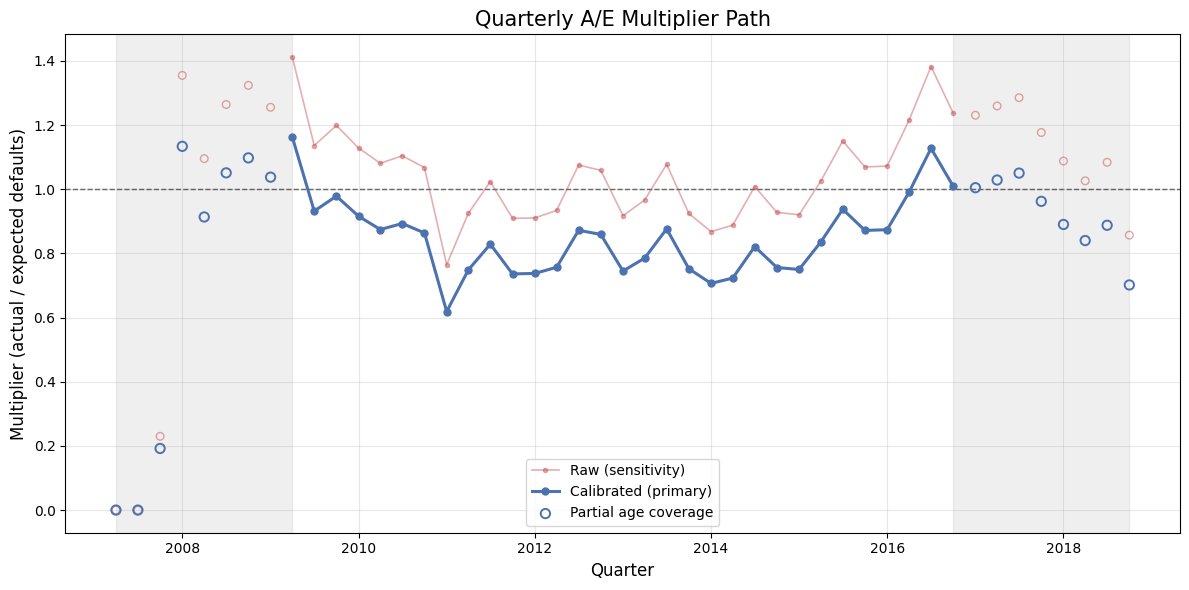

In [37]:
# Figure 2.1 — multiplier path (calibrated primary; partial-coverage flagged)
qdf = quarter_df.sort_values("quarter_start").reset_index(drop=True)
clean = qdf[qdf["full_age_mix"]]
part  = qdf[~qdf["full_age_mix"]]

fig, ax = plt.subplots(figsize=(12, 6))

# Reference line at 1.0
ax.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.7, zorder=1)

# Shade leading / trailing partial-coverage regions
if len(clean) and len(part):
    first_clean = clean["quarter_start"].min()
    last_clean  = clean["quarter_start"].max()
    xmin, xmax = qdf["quarter_start"].min(), qdf["quarter_start"].max()
    lead = part[part["quarter_start"] < first_clean]
    trail = part[part["quarter_start"] > last_clean]
    if len(lead):
        ax.axvspan(xmin, first_clean, color="grey", alpha=0.12, zorder=0)
    if len(trail):
        ax.axvspan(last_clean, xmax, color="grey", alpha=0.12, zorder=0)

# Raw sensitivity — light line across clean quarters
ax.plot(clean["quarter_start"], clean["multiplier_raw"],
        color="#C44E52", linewidth=1.2, alpha=0.45, marker="o", markersize=3,
        label="Raw (sensitivity)", zorder=2)

# Calibrated primary — solid on clean quarters
ax.plot(clean["quarter_start"], clean["multiplier_calibrated"],
        color="#4C72B0", linewidth=2.2, marker="o", markersize=5,
        label="Calibrated (primary)", zorder=4)

# Partial-coverage quarters — hollow markers (both targets) so they're flagged
if len(part):
    ax.scatter(part["quarter_start"], part["multiplier_calibrated"],
               facecolors="none", edgecolors="#4C72B0", s=45, linewidths=1.4,
               label="Partial age coverage", zorder=5)
    ax.scatter(part["quarter_start"], part["multiplier_raw"],
               facecolors="none", edgecolors="#C44E52", s=30, linewidths=1.0,
               alpha=0.5, zorder=3)

ax.set_title("Quarterly A/E Multiplier Path", fontsize=15)
ax.set_xlabel("Quarter", fontsize=12)
ax.set_ylabel("Multiplier (actual / expected defaults)", fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure2.1_multiplier_path.png"),
            dpi=300, bbox_inches="tight")
plt.show()


### Figure 2.2 — Coefficient stability (unemployment)

The `unrate_diff_l1` coefficient across M1–M5 on the baseline sample, with HAC 95%
intervals. Calibrated (primary) and raw (sensitivity) are overlaid — near-identical
estimates are the visual evidence that the macro slope is invariant to the calibration
choice. The vertical line at 0 marks the no-effect threshold.

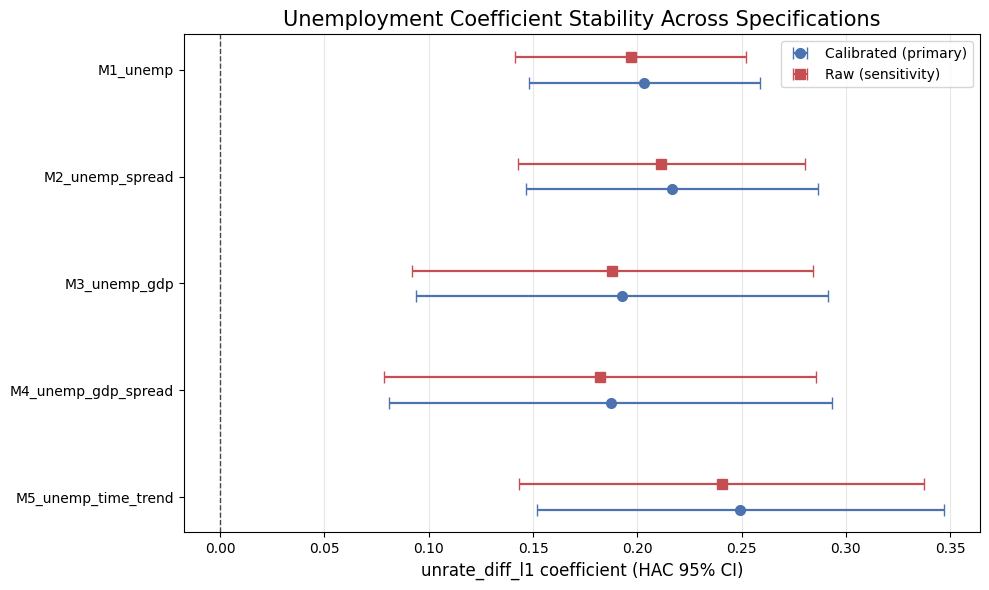

In [38]:
# Figure 2.2 — coefficient stability for unrate_diff_l1 (baseline, M1-M5)
ci = baseline_coef_table[baseline_coef_table["term"] == "unrate_diff_l1"].copy()
ci["ci95"] = 1.96 * ci["std_err_HAC"]

model_order = ["M1_unemp", "M2_unemp_spread", "M3_unemp_gdp",
               "M4_unemp_gdp_spread", "M5_unemp_time_trend"]
ypos = {m: i for i, m in enumerate(model_order)}

fig, ax = plt.subplots(figsize=(10, 6))
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)

style = {
    "calibrated": dict(color="#4C72B0", marker="o", label="Calibrated (primary)", dy=+0.12),
    "raw":        dict(color="#C44E52", marker="s", label="Raw (sensitivity)",    dy=-0.12),
}
for tgt, st in style.items():
    sub = ci[ci["target"] == tgt]
    ys = [ypos[m] + st["dy"] for m in sub["model_id"]]
    ax.errorbar(sub["coef"], ys, xerr=sub["ci95"], fmt=st["marker"],
                color=st["color"], capsize=4, markersize=7, linewidth=1.6,
                label=st["label"])

ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order)
ax.invert_yaxis()
ax.set_xlabel("unrate_diff_l1 coefficient (HAC 95% CI)", fontsize=12)
ax.set_title("Unemployment Coefficient Stability Across Specifications", fontsize=15)
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure2.2_coefficient_stability.png"),
            dpi=300, bbox_inches="tight")
plt.show()


### Figure 2.3 — Multiplier vs. unemployment scatter

Each clean quarter's log calibrated multiplier against the lagged change in unemployment,
with the M1 OLS fit line. This is the visual counterpart of the coefficient table: an
upward slope is the unemployment channel.

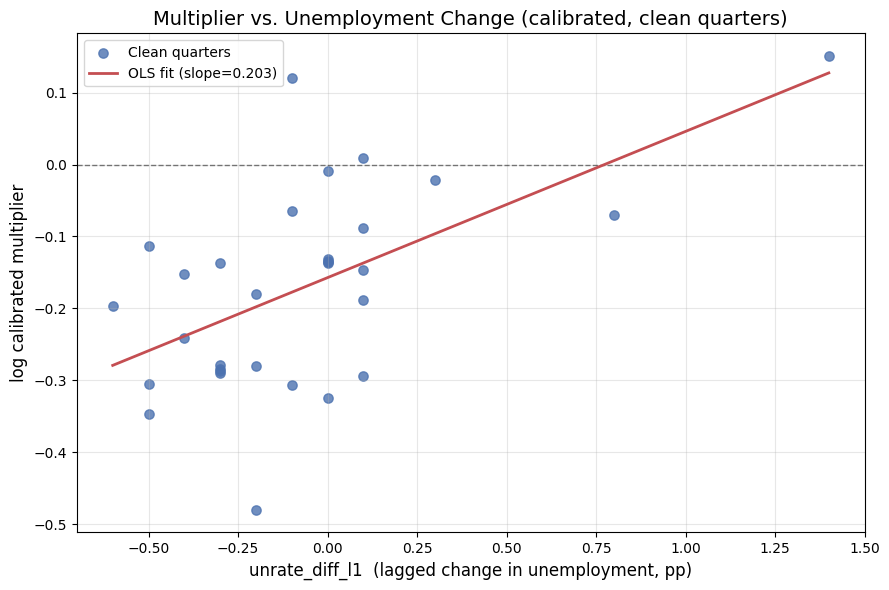

In [39]:
# Figure 2.3 — log calibrated multiplier vs unemployment change (baseline sample)
sc = macro_reg_df.copy()
sc = sc[(sc["multiplier_calibrated"] > 0) & sc["unrate_diff_l1"].notna()]
x = sc["unrate_diff_l1"].values
y = np.log(sc["multiplier_calibrated"].values)

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)  # log(1)=0
ax.scatter(x, y, color="#4C72B0", s=45, alpha=0.8, label="Clean quarters")

# OLS fit line (M1 form: log multiplier ~ unrate_diff_l1)
if len(x) >= 2:
    b1, b0 = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, b0 + b1 * xs, color="#C44E52", linewidth=2,
            label=f"OLS fit (slope={b1:.3f})")

ax.set_xlabel("unrate_diff_l1  (lagged change in unemployment, pp)", fontsize=12)
ax.set_ylabel("log calibrated multiplier", fontsize=12)
ax.set_title("Multiplier vs. Unemployment Change (calibrated, clean quarters)", fontsize=14)
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figure2.3_multiplier_vs_unemp.png"),
            dpi=300, bbox_inches="tight")
plt.show()


### Verification — confirm artifacts written

In [40]:
# Verify every expected artifact landed in the folder (and nothing in the cwd)
expected = [
    "table2.1_default_age_curve.csv",
    "table2.2_multiplier_path.csv",
    "table2.3_satellite_coefficients.csv",
    "table2.3b_unemployment_coefficient_focus.csv",
    "table2.4_model_comparison.csv",
    "figure2.1_multiplier_path.png",
    "figure2.2_coefficient_stability.png",
    "figure2.3_multiplier_vs_unemp.png",
]
present = set(os.listdir(ARTIFACT_DIR))
missing = [f for f in expected if f not in present]
print(f"Artifact folder: {os.path.abspath(ARTIFACT_DIR)}")
print(f"Expected: {len(expected)}  Found in folder: {len(present)}")
print("MISSING:" if missing else "All expected artifacts present.")
for f in missing:
    print("   -", f)
print("\nFolder contents:")
for f in sorted(present):
    print("   ", f)


Artifact folder: c:\Users\shanx\Dropbox\STG\STG26CODES\Git\Projects\StressTesting\artifacts_component2
Expected: 8  Found in folder: 12
All expected artifacts present.

Folder contents:
    figure2.1_multiplier_path.png
    figure2.2_coefficient_stability.png
    figure2.3_multiplier_vs_unemp.png
    supp_all_coefficients.csv
    supp_all_model_comparison.csv
    supp_robust_coefficients.csv
    supp_robust_model_comparison.csv
    table2.1_default_age_curve.csv
    table2.2_multiplier_path.csv
    table2.3_satellite_coefficients.csv
    table2.3b_unemployment_coefficient_focus.csv
    table2.4_model_comparison.csv
